In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"haseeb1708","key":"10b6ce0b444a9425156eb92e02ae0021"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d khoongweihao/covid19-xray-dataset-train-test-sets
!unzip covid19-xray-dataset-train-test-sets.zip

Dataset URL: https://www.kaggle.com/datasets/khoongweihao/covid19-xray-dataset-train-test-sets
License(s): CC0-1.0
  0% 0.00/84.3M [00:00<?, ?B/s]
100% 84.3M/84.3M [00:00<00:00, 1.74GB/s]
Archive:  covid19-xray-dataset-train-test-sets.zip
  inflating: xray_dataset_covid19/test/NORMAL/NORMAL2-IM-0035-0001.jpeg  
  inflating: xray_dataset_covid19/test/NORMAL/NORMAL2-IM-0052-0001.jpeg  
  inflating: xray_dataset_covid19/test/NORMAL/NORMAL2-IM-0058-0001.jpeg  
  inflating: xray_dataset_covid19/test/NORMAL/NORMAL2-IM-0059-0001.jpeg  
  inflating: xray_dataset_covid19/test/NORMAL/NORMAL2-IM-0072-0001.jpeg  
  inflating: xray_dataset_covid19/test/NORMAL/NORMAL2-IM-0073-0001.jpeg  
  inflating: xray_dataset_covid19/test/NORMAL/NORMAL2-IM-0092-0001.jpeg  
  inflating: xray_dataset_covid19/test/NORMAL/NORMAL2-IM-0105-0001.jpeg  
  inflating: xray_dataset_covid19/test/NORMAL/NORMAL2-IM-0110-0001.jpeg  
  inflating: xray_dataset_covid19/test/NORMAL/NORMAL2-IM-0111-0001.jpeg  
  inflating: xray_dat

In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/covid19-xray-dataset-train-test-sets.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [ ]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
conv_base.trainable = False

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [ ]:
batch_size = 32

train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        '/content/xray_dataset_covid19/train',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        '/content/xray_dataset_covid19/test',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

Found 148 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.4340 - loss: 1.8556 - val_accuracy: 0.5000 - val_loss: 0.9359
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 997ms/step - accuracy: 0.6118 - loss: 0.8094 - val_accuracy: 0.7250 - val_loss: 0.4351
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7920 - loss: 0.3776 - val_accuracy: 0.9500 - val_loss: 0.1517
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 875ms/step - accuracy: 0.9133 - loss: 0.2065 - val_accuracy: 0.9250 - val_loss: 0.1453
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9132 - loss: 0.1668 - val_accuracy: 0.9500 - val_loss: 0.1226
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9613 - loss: 0.1339 - val_accuracy: 0.9500 - val_loss: 0.1137
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 960ms/step - accuracy: 0.9672 - loss: 0.1076 - val_accuracy: 0.9750 - val_loss: 0.0861
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 862ms/step - accuracy: 0.9440 - loss: 0.1398 - val_accuracy: 0.9750 - val_loss: 0.0735
Epo

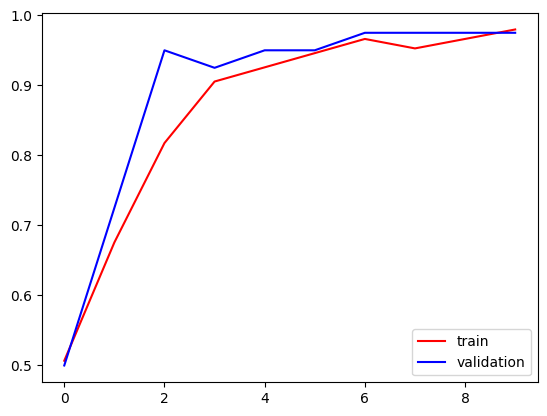

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

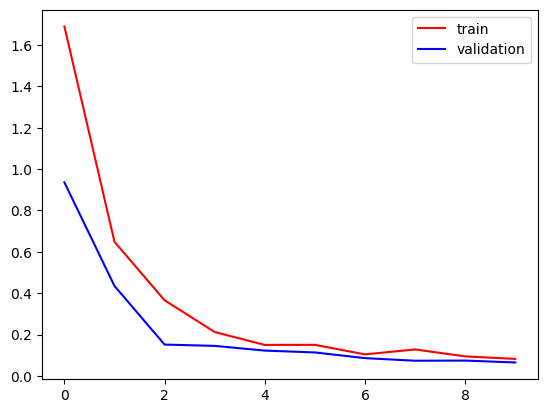

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"haseeb1708","key":"10b6ce0b444a9425156eb92e02ae0021"}'}

In [ ]:
import os, shutil, pathlib
original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("xray_dataset_covid19")


In [ ]:
def make_subset(subset_name, start_index, end_index):
    for category in ("NORMAL", "PNEUMONIA"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir, exist_ok=True)  # ✅ FIX

        fnames = [f"{category}.{i}.jpg"
                  for i in range(start_index, end_index)]

        for fname in fnames:
            shutil.copyfile(
                src=original_dir / category / fname,
                dst=dir / fname
            )


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [ ]:
# from tensorflow.keras.utils import image_dataset_from_directory

# train_dataset = image_dataset_from_directory(
#     new_base_dir / "train",
#     labels="inferred",
#     label_mode="binary",
#     image_size=(180, 180),
#     batch_size=32,
#     shuffle=True
# )

# validation_dataset = image_dataset_from_directory(
#     new_base_dir / "validation",
#     labels="inferred",
#     label_mode="binary",
#     image_size=(180, 180),
#     batch_size=32,
#     shuffle=True
# )

# test_dataset = image_dataset_from_directory(
#     new_base_dir / "test",
#     labels="inferred",
#     label_mode="binary",
#     image_size=(180, 180),
#     batch_size=32,
#     shuffle=False
# )
model.fit(
    train_dataset,
    epochs=10
)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5599 - loss: 0.9760
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 366ms/step - accuracy: 0.5356 - loss: 0.6912
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 327ms/step - accuracy: 0.4860 - loss: 0.6888
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 387ms/step - accuracy: 0.5441 - loss: 0.6834
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 545ms/step - accuracy: 0.5667 - loss: 0.6586
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 438ms/step - accuracy: 0.5727 - loss: 0.6644
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 310ms/step - accuracy: 0.6072 - loss: 0.6691
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 363ms/step - accuracy: 0.7027 - loss: 0.6171
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 386ms/step - accuracy: 0.7697 - loss: 0.5051
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 374ms/step - accuracy: 0.8017 - loss: 0.4010


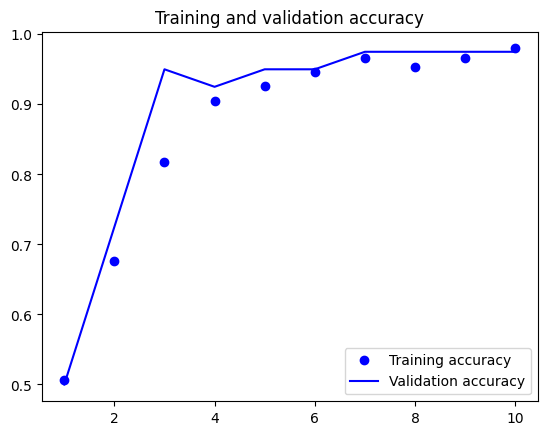

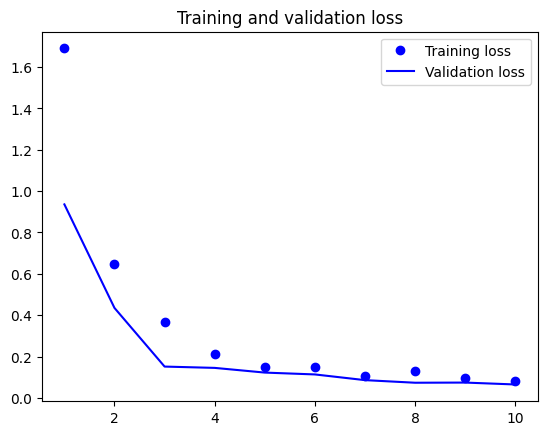

In [ ]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()